In [2]:
# from autocvd import autocvd
# autocvd(num_gpus = 1, interval=1)
import os
os.environ['CUDA_VISIBLE_DEVICES'] = '4'

import numpy as np
import matplotlib.pyplot as plt
import time 
from functools import partial  # Change this line - lowercase 'partial'

import jax.numpy as jnp
import jax
from jax import jit

# jax.config.update("jax_enable_x64", True)
from jax.sharding import Mesh, PartitionSpec, NamedSharding         #IMPORT NEEDED FOR AUTOMATIC PARALLELISM
from jax.experimental import shard_map



import pandas as pd
import seaborn as sns
from chainconsumer import Chain, ChainConsumer, Truth



from odisseo import construct_initial_state
from odisseo.dynamics import  DIRECT_ACC_MATRIX, DIRECT_ACC_LAXMAP
from odisseo.option_classes import SimulationConfig, SimulationParams, MNParams, NFWParams, PlummerParams, PSPParams, MN_POTENTIAL, NFW_POTENTIAL, PSP_POTENTIAL
from odisseo.initial_condition import Plummer_sphere
from odisseo.time_integration import time_integration
from odisseo.units import CodeUnits
from odisseo.utils import projection_on_GD1
from astropy import units as u

In [3]:
code_length = 10.0 * u.kpc
code_mass = 1e4 * u.Msun
code_time = 3 * u.Gyr
code_units = CodeUnits(code_length, code_mass, G=1, unit_time = code_time )  
N_particles = 1000

pos_com_final = jnp.array([[11.8, 0.79, 6.4]]) * u.kpc.to(code_units.code_length)
vel_com_final = jnp.array([[109.5,-254.5,-90.3]]) * (u.km/u.s).to(code_units.code_velocity)

config_sim = SimulationConfig(N_particles = N_particles,
                            return_snapshots = False, 
                            num_timesteps = 1000, 
                            external_accelerations=(NFW_POTENTIAL, MN_POTENTIAL, PSP_POTENTIAL), 
                            acceleration_scheme = DIRECT_ACC_MATRIX,
                            softening = (0.1 * u.pc).to(code_units.code_length).value,) #default values
        #the center of mass needs to be integrated backwards in time first 
config_com = config_sim._replace(N_particles=1,)

@jit
def run_simulation(rng_key, params):
    params_samples = SimulationParams(t_end = params[0] * u.Gyr.to(code_units.code_time),
                        Plummer_params = PlummerParams(Mtot=params[1] * u.Msun.to(code_units.code_mass),
                                                       a = params[2] * u.kpc.to(code_units.code_length),),
                        NFW_params = NFWParams(Mvir=params[3] * u.Msun.to(code_units.code_mass),
                                               r_s= params[4] * u.kpc.to(code_units.code_length)),
                        MN_params = MNParams(M = params[5] * u.Msun.to(code_units.code_mass),
                                             a = params[6] * u.kpc.to(code_units.code_length),
                                            b = (0.280 * u.kpc).to(code_units.code_length).value),
                        PSP_params= PSPParams(M = 4501365375.06545 * u.Msun.to(code_units.code_mass),
                                                alpha = 1.8, 
                                                r_c = (1.9*u.kpc).to(code_units.code_length).value),  
                        G = code_units.G, )

    params_com = params_samples._replace(t_end=-params_samples.t_end,)
    mass_com = jnp.array([params_samples.Plummer_params.Mtot]) 
    
    #we construmt the initial state of the com 
    initial_state_com = construct_initial_state(pos_com_final, vel_com_final,)
    #we run the simulation backwards in time for the center of mass
    final_state_com = time_integration(initial_state_com, mass_com, config=config_com, params=params_com)
    #we calculate the final position and velocity of the center of mass
    pos_com = final_state_com[:, 0]
    vel_com = final_state_com[:, 1]

    #we construct the initial state of the Plummer sphere
    positions, velocities, mass = Plummer_sphere(key=rng_key, params=params_samples, config=config_sim)
    #we add the center of mass position and velocity to the Plummer sphere particles
    positions = positions + pos_com
    velocities = velocities + vel_com
    #initialize the initial state
    initial_state_stream = construct_initial_state(positions, velocities, )
    #run the simulation
    final_state = time_integration(initial_state_stream, mass, config=config_sim, params=params_samples)

    #projection on the GD1 stream
    stream = projection_on_GD1(final_state, code_units=code_units,)

    return stream

def log_diag_multivariate_normal(x, mean, sigma):
        """
        Log PDF of a multivariate Gaussian with diagonal covariance.
        
        Parameters
        ----------
        x : (D,)
        mean : (D,)
        sigma : (D,)  # standard deviations for each dimension
        """
        diff = (x - mean) / sigma
        D = x.shape[0]
        log_det = 2.0 * jnp.sum(jnp.log(sigma))
        norm_const = -0.5 * (D * jnp.log(2 * jnp.pi) + log_det)
        exponent = -0.5 * jnp.sum(diff**2)
        return norm_const + exponent

@jit
def stream_likelihood(model_stream, obs_stream, obs_errors, ):
    """
    Log-likelihood of observed stars given simulated stream (diagonal covariance).
    
    Parameters
    ----------
    model_stream : (N_model, D)
    obs_stream : (N_obs, D)
    obs_errors : (N_obs, D)   # per-dimension standard deviations
    tau : float
        Stream membership fraction
    p_field : float
        Background probability density
    """
    def obs_log_prob(obs, sigma):
        def model_log_prob(model_point):
            return log_diag_multivariate_normal(obs, model_point, sigma)

        # Compute log_probs for all model points
        log_probs = jax.vmap(model_log_prob)(model_stream)
        
        # Numerically stable average: log(mean(exp(log_probs)))
        log_p_stream = jax.scipy.special.logsumexp(log_probs) - jnp.log(model_stream.shape[0])
        
        # Mixture model
        # p_total = tau * jnp.exp(log_p_stream) + (1 - tau) * p_field
        p_total = jnp.exp(log_p_stream)
        return jnp.log(p_total + 1e-30)

    # Vectorize over observations
    logL_values = jax.vmap(obs_log_prob)(obs_stream, jnp.repeat(obs_errors, obs_stream.shape[0]).reshape(-1, 6))
    return jnp.sum(logL_values)


true_GD1_observation_path = '/export/data/vgiusepp/odisseo_data/data_fix_position/true.npz'
observation = jnp.array(np.load(true_GD1_observation_path)['x'][:1000]).reshape(1, 1000, 6)
true_theta = jnp.array(np.load(true_GD1_observation_path)['theta'][:1000])

@jit
def evaluate_loglikelihood(rng_key, observation, theta_1, ):

        key, sk = jax.random.split(rng_key)
        # print(f"In the corrector: theta_1 shape: {theta_1.shape}, target shape: {target.shape}")
        output = run_simulation(key, theta_1)

        return stream_likelihood(model_stream=output, obs_stream=observation, obs_errors=jnp.array([0.25, 0.001, 0.15, 5., 0.1, 0.0001]))



In [3]:
# True parameter values (without code_units transformation)
true_params = jnp.array([
    3.0,                    # t_end (Gyr)
    10**4.05,              # Plummer Mtot (Msun) 
    8.0 * 1e-3,            # Plummer a (kpc) - converted from pc to kpc
    4.3683325e11,          # NFW Mvir (Msun)
    16.0,                  # NFW r_s (kpc)
    68_193_902_782.346756, # MN M (Msun)
    3.0,                   # MN a (kpc)
])

# Prior bounds for each parameter
prior_bounds = jnp.array([
    [0.5, 5.0],                    # t_end: 0.5 to 5 Gyr
    [10**3, 10**4.5],              # Plummer Mtot: 10^3 to 10^4.5 Msun
    [8.0 * 1e-3 * 0.25, 8.0 * 1e-3 * 2.0],  # Plummer a: 1/4 to 2x true (kpc)
    [4.3683325e11 * 0.25, 4.3683325e11 * 2.0],  # NFW Mvir: 1/4 to 2x true
    [16.0 * 0.25, 16.0 * 2.0],    # NFW r_s: 1/4 to 2x true (kpc)
    [68_193_902_782.346756 * 0.25, 68_193_902_782.346756 * 2.0],  # MN M: 1/4 to 2x true
    [3.0 * 0.25, 3.0 * 2.0],      # MN a: 1/4 to 2x true (kpc)
])  # Shape: (7, 2) for [min, max] bounds

def draw_from_prior(key):
    """Draw samples from uniform prior."""
    key, subkey = jax.random.split(key)
    u = jax.random.uniform(subkey, shape=(7,))
    
    # Transform uniform [0,1] to [min, max] for each parameter
    samples = prior_bounds[:, 0] + u * (prior_bounds[:, 1] - prior_bounds[:, 0])
    return samples

@jit
def evaluate_log_prior(theta):
    """Evaluate log prior density (uniform)."""
    # Check if all parameters are within bounds
    in_bounds = jnp.all((theta >= prior_bounds[:, 0]) & (theta <= prior_bounds[:, 1]))
    
    # For uniform distribution: log(density) = -log(volume)
    # Volume = product of interval widths
    log_volume = jnp.sum(jnp.log(prior_bounds[:, 1] - prior_bounds[:, 0]))
    
    # Return -inf if out of bounds, -log_volume if in bounds
    return jnp.where(in_bounds, -log_volume, -jnp.inf)


def draw_from_proposal(key, theta, sigma2_prop):
    key, sk = jax.random.split(key)
    theta_prime = jax.random.normal(sk, shape=theta.shape) * jnp.sqrt(sigma2_prop) + theta
    return theta_prime, key

@jit
def evaluate_log_posterior_grad(rng_key, observation, theta):
    """Compute gradient of log posterior."""
    
    def log_posterior(theta):
        log_prior = evaluate_log_prior(theta)
        log_like = evaluate_loglikelihood(rng_key, observation, theta)
        return log_prior + log_like
    
    # Get both value and gradient
    log_post_val, grad = jax.value_and_grad(log_posterior)(theta)
    return log_post_val, grad

@jit
def evaluate_log_posterior(rng_key, observation, theta):
    log_prior = evaluate_log_prior(theta)
    log_like = evaluate_loglikelihood(rng_key, observation, theta)
    return log_prior + log_like


@partial(jax.jit, static_argnames=('n_steps', 'step_size', 'grad_log_prob_fn',))
def leapfrog(params, momentum, key, observation, grad_log_prob_fn, step_size, n_steps):
    """Approximates Hamiltonian dynamics using the leapfrog algorithm."""

    # define a single step
    def step(i, args):
        params, momentum = args

        # update momentum
        grad = grad_log_prob_fn(key, observation, params)[1]
        # momentum = tree_map(lambda m, g: m + 0.5 * step_size * g, momentum, grad)
        momentum = momentum + 0.5 * step_size * grad

        # update params
        # params = tree_map(lambda p, m: p + m * step_size, params, momentum)
        params = params + momentum * step_size

        # update momentum
        grad = grad_log_prob_fn(key, observation, params)[1]
        # momentum = tree_map(lambda m, g: m + 0.5 * step_size * g, momentum, grad)

        momentum = momentum + 0.5 * step_size * grad

        return params, momentum

    # do 'n_steps'
    new_params, new_momentum = jax.lax.fori_loop(0, n_steps, step, (params, momentum))

    return new_params, new_momentum

@partial(jax.jit, static_argnames=('num_steps',))
def posterior_hmc(observation, key, num_steps):

    # initialize theta from prior with a split key (keep `key` for the chain)
    key, subkey = jax.random.split(key)
    theta_0 = draw_from_prior(subkey)

    # Calculate rough standard deviations from your prior bounds
    prior_stds = (prior_bounds[:, 1] - prior_bounds[:, 0]) / 4  # Rough estimate

    # Use as initial proposal sigmas (different for each parameter)
    sigma2_prop_vector = (prior_stds * 0.1) ** 2  # Start with 10% of range

    # sigma2_prop_vector = 1.

    def scan_step(carry, _):
        theta, key = carry

        # Compute initial momentum
        momentum = jax.random.normal(key, shape=theta.shape) * jnp.sqrt(sigma2_prop_vector)

        key_leapfrog, key = jax.random.split(key)

        # Perform the leapfrog integration
        theta_prime, momentum_prime = leapfrog(theta, momentum, key=key_leapfrog, observation=observation, grad_log_prob_fn=evaluate_log_posterior_grad, step_size=0.001, n_steps=10)

        # split for the accept/reject uniform
        uniform_key, momentum_key, momentum_prime_key = jax.random.split(key, 3)

        potentaial_energy_diff = evaluate_log_posterior(momentum_prime_key, theta=theta_prime, observation=observation ) - evaluate_log_posterior(momentum_key, theta=theta, observation=observation)
        momentum_dot = jnp.sum(momentum**2)
        momentum_prime_dot = jnp.sum(momentum_prime**2)
        kinetic_energy_diff = 0.5 * (- momentum_prime_dot + momentum_dot)
        log_accept_prob = potentaial_energy_diff + kinetic_energy_diff
        log_accept_prob = jnp.nan_to_num(log_accept_prob, nan=-jnp.inf)
        accept_prob = jnp.minimum(1, jnp.exp(log_accept_prob))
        accept = jax.random.uniform(uniform_key) < accept_prob
        theta_new = jnp.where(accept, theta_prime, theta)

        return (theta_new, subkey), theta_new


    (theta_final, _), chain = jax.lax.scan(scan_step, (theta_0, key), None, length=num_steps)

    return chain

In [ ]:
# up until num_chains on the order of
# the < number of cuda cores*, num_chains
# does not negatively impact the runtime
# of the sampling because we vmap over all chains! -
# and on an A100 GPU thats ~7000 cores
num_chains = 4

# the runtime scales linearly with
# num_steps
# num_steps = 10000
# burn_in = 5000

num_steps = 10_000
burn_in = 1

# total num samples
num_samples = num_chains * (num_steps - burn_in)
print(f"Total number of samples: {num_samples}")

key = jax.random.PRNGKey(0)
# create independent keys for each chain
keys = jax.random.split(key, num_chains)

#SHARD THE INPUT OF THE SIMULATION
mesh = Mesh(np.array(jax.devices()), ("n_sim",))                                                                  
keys = jax.device_put(keys, NamedSharding(mesh, PartitionSpec("n_sim")))

# vmap over the keys, each one runs a full chain
# we wrap posterior_mcmc to only take key as input
def run_chain(single_key):
    return posterior_hmc(observation, single_key, num_steps)

# vectorized map over chains
all_chains = jax.vmap(run_chain)(keys)  # shape (num_chains, num_steps, theta_dim)

# discard burn-in
all_chains_post = all_chains[:, burn_in:, :]  # shape (num_chains, num_steps - burn_in, theta_dim)

# concatenate along the chain axis
example_chain = all_chains_post.reshape(-1, all_chains_post.shape[-1])

# A modern ML GPU consists of several Streaming Multiprocessors or SMs
# e.g. 108 on an A100 which can operate totally independent. These
# are separated into quadrants (subpartitions) each with a tensor core and a
# SIMD/SIMT vector arithmetic unit whose lanes NVIDIA calls CUDA cores -
# per cycle all those cuda cores per quadrant must perform the same operation,
# different operations (up to 16 per subpartition are possible)
# means stalling a part of the CUDA cores (on the quadrant
# level)

Total number of samples: 39996


In [ ]:
all_chains 

Array([[[4.35357332e+00, 1.58903604e+04, 1.55156460e-02, 1.75522513e+11,
         4.80956602e+00, 1.35682941e+11, 1.66481876e+00],
        [4.35215712e+00, 1.58872842e+04, 1.55117251e-02, 1.75690449e+11,
         4.80353403e+00, 1.35693263e+11, 1.66605258e+00],
        [4.35074091e+00, 1.58842080e+04, 1.55078042e-02, 1.75858385e+11,
         4.79750204e+00, 1.35703585e+11, 1.66728640e+00],
        [4.34932470e+00, 1.58811318e+04, 1.55038834e-02, 1.76026321e+11,
         4.79147005e+00, 1.35713907e+11, 1.66852021e+00],
        [4.34790850e+00, 1.58780557e+04, 1.54999625e-02, 1.76194257e+11,
         4.78543806e+00, 1.35724229e+11, 1.66975403e+00],
        [4.34649229e+00, 1.58749795e+04, 1.54960416e-02, 1.76362193e+11,
         4.77940607e+00, 1.35734551e+11, 1.67098784e+00],
        [4.34507608e+00, 1.58719033e+04, 1.54921208e-02, 1.76530129e+11,
         4.77337408e+00, 1.35744872e+11, 1.67222166e+00],
        [4.34365988e+00, 1.58688271e+04, 1.54881999e-02, 1.76698065e+11,
         4

Parameter $M_{plummer}$ in chain Experimental Results is not constrained
Parameter $a_{plummer}$ in chain Experimental Results is not constrained
Parameter $M_{NFW}$ in chain Experimental Results is not constrained
Parameter $r_{NFW}$ in chain Experimental Results is not constrained
Parameter $M_{MN}$ in chain Experimental Results is not constrained
Parameter $a_{MN}$ in chain Experimental Results is not constrained


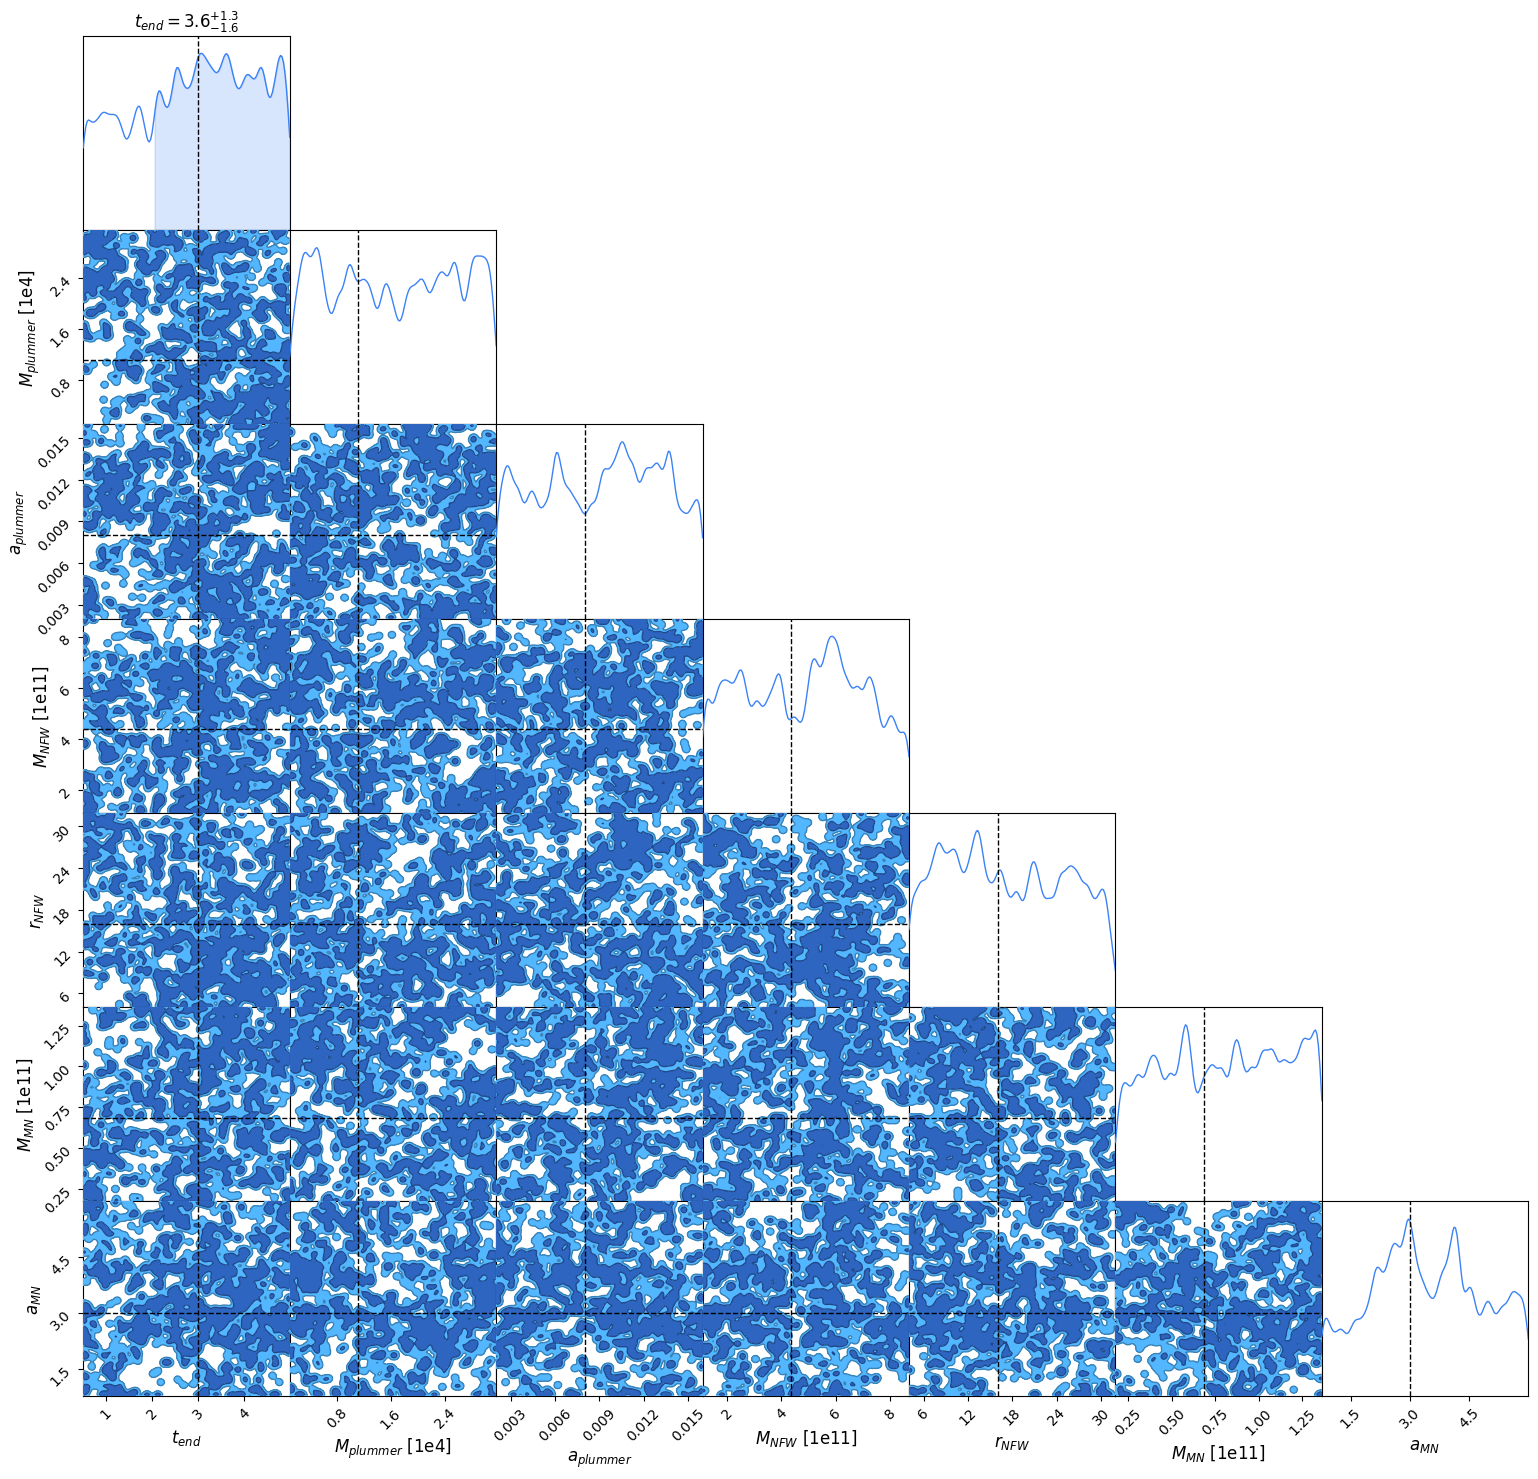

In [ ]:
thin = 10
example_chain_thin = example_chain[::thin]

# convert JAX array to numpy
chain_np = np.array(example_chain_thin)

df = pd.DataFrame(chain_np, columns=['$t_{end}$', '$M_{plummer}$', '$a_{plummer}$', '$M_{NFW}$', '$r_{NFW}$', '$M_{MN}$', '$a_{MN}$'])
df = df.astype(float)
# Convert to float and handle any non-numeric columns
numeric_df = df.select_dtypes(include=[np.number])
if numeric_df.empty:
    # If no numeric columns, convert all to float
    numeric_df = df.astype(float)
# Create corner plot with ChainConsumer
c = ChainConsumer()
c.add_chain(Chain(samples=numeric_df, name="Experimental Results", ), )
c.add_truth(Truth(location={
        '$t_{end}$': true_theta[0] * code_units.code_time.to(u.Gyr),
        '$M_{plummer}$': true_theta[1] * code_units.code_mass.to(u.Msun),
        '$a_{plummer}$': true_theta[2] * code_units.code_length.to(u.kpc),
        '$M_{NFW}$': true_theta[3] * code_units.code_mass.to(u.Msun),
        '$r_{NFW}$': true_theta[4] * code_units.code_length.to(u.kpc),
        '$M_{MN}$': true_theta[5] * code_units.code_mass.to(u.Msun),
        '$a_{MN}$': true_theta[6] * code_units.code_length.to(u.kpc),
}))
fig = c.plotter.plot()   




# # add ground truth (blue lines)
# for i, var_row in enumerate(df.columns):
#     for j, var_col in enumerate(df.columns[:i+1]):
#         ax = g.axes[i, j]

#         # diagonal: only vertical line at truth
#         if i == j:
#             ax.axvline(true_theta[j], color="blue", linestyle="--")

#         # off-diagonal: both horizontal and vertical lines
#         else:
#             ax.axvline(true_theta[j], color="blue", linestyle="--")
            # ax.axhline(true_theta[i], color="blue", linestyle="--")

/export/home/vgiusepp/miniconda3/envs/sbi_sim/lib/python3.12/site-packages/arviz/stats/diagnostics.py:990: RuntimeWarning: overflow encountered in square
  varvar = ((sims_c2**2).mean() - evar**2) / ess_mean_sims
/export/home/vgiusepp/miniconda3/envs/sbi_sim/lib/python3.12/site-packages/arviz/stats/diagnostics.py:990: RuntimeWarning: overflow encountered in scalar power
  varvar = ((sims_c2**2).mean() - evar**2) / ess_mean_sims
/export/home/vgiusepp/miniconda3/envs/sbi_sim/lib/python3.12/site-packages/arviz/stats/diagnostics.py:990: RuntimeWarning: invalid value encountered in scalar subtract
  varvar = ((sims_c2**2).mean() - evar**2) / ess_mean_sims
/export/home/vgiusepp/miniconda3/envs/sbi_sim/lib/python3.12/site-packages/arviz/stats/diagnostics.py:990: RuntimeWarning: overflow encountered in square
  varvar = ((sims_c2**2).mean() - evar**2) / ess_mean_sims
/export/home/vgiusepp/miniconda3/envs/sbi_sim/lib/python3.12/site-packages/arviz/stats/diagnostics.py:990: RuntimeWarning: overf

                       mean            sd        hdi_3%       hdi_97%  \
$t_{end}$      2.918000e+00  1.276000e+00  8.110000e-01  4.983000e+00   
$M_{plummer}$  1.644290e+04  9.093040e+03  2.426696e+03  3.090425e+04   
$a_{plummer}$  9.000000e-03  4.000000e-03  3.000000e-03  1.600000e-02   
$M_{NFW}$      4.822390e+11  2.139021e+11  1.094932e+11  8.094220e+11   
$r_{NFW}$      1.723200e+01  7.938000e+00  5.045000e+00  3.074800e+01   
$M_{MN}$       7.969142e+10  3.459714e+10  2.439755e+10  1.349102e+11   
$a_{MN}$       3.431000e+00  1.396000e+00  1.199000e+00  5.997000e+00   

                  mcse_mean  mcse_sd  ess_bulk  ess_tail  r_hat  
$t_{end}$      2.600000e-02    0.013    2322.0    2322.0   3.46  
$M_{plummer}$  1.886830e+02   79.971    2322.0    2322.0   3.33  
$a_{plummer}$  0.000000e+00    0.000    2322.0    2322.0   3.24  
$M_{NFW}$      4.438537e+09      NaN    2322.0    2322.0   3.24  
$r_{NFW}$      1.650000e-01    0.073    2322.0    2322.0   3.37  
$M_{MN}$       7.17

/export/home/vgiusepp/miniconda3/envs/sbi_sim/lib/python3.12/site-packages/arviz/plots/plot_utils.py:270: UserWarning: rcParams['plot.max_subplots'] (40) is smaller than the number of variables to plot (700) in plot_autocorr, generating only 40 plots
  warnings.warn(


ValueError: could not broadcast input array from shape (9,) into shape (10,)

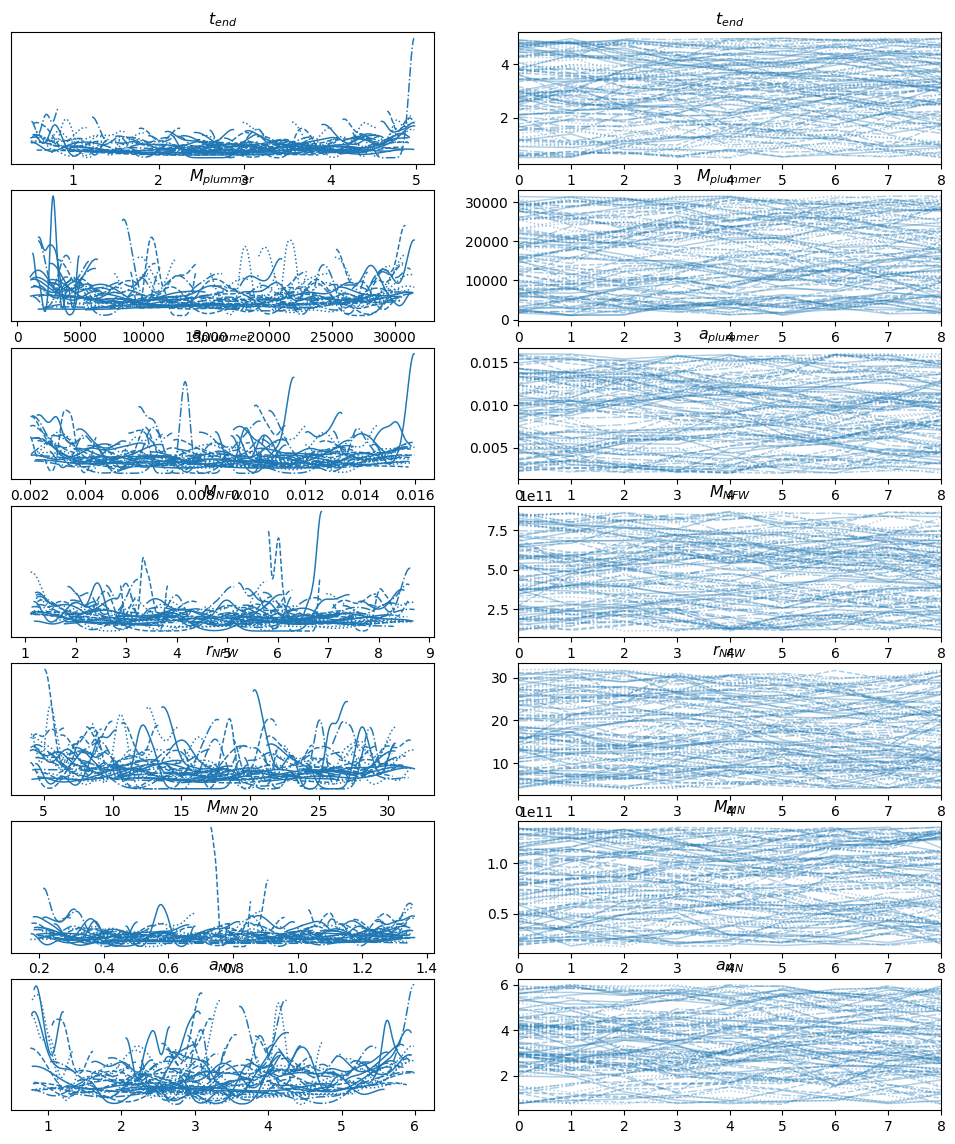

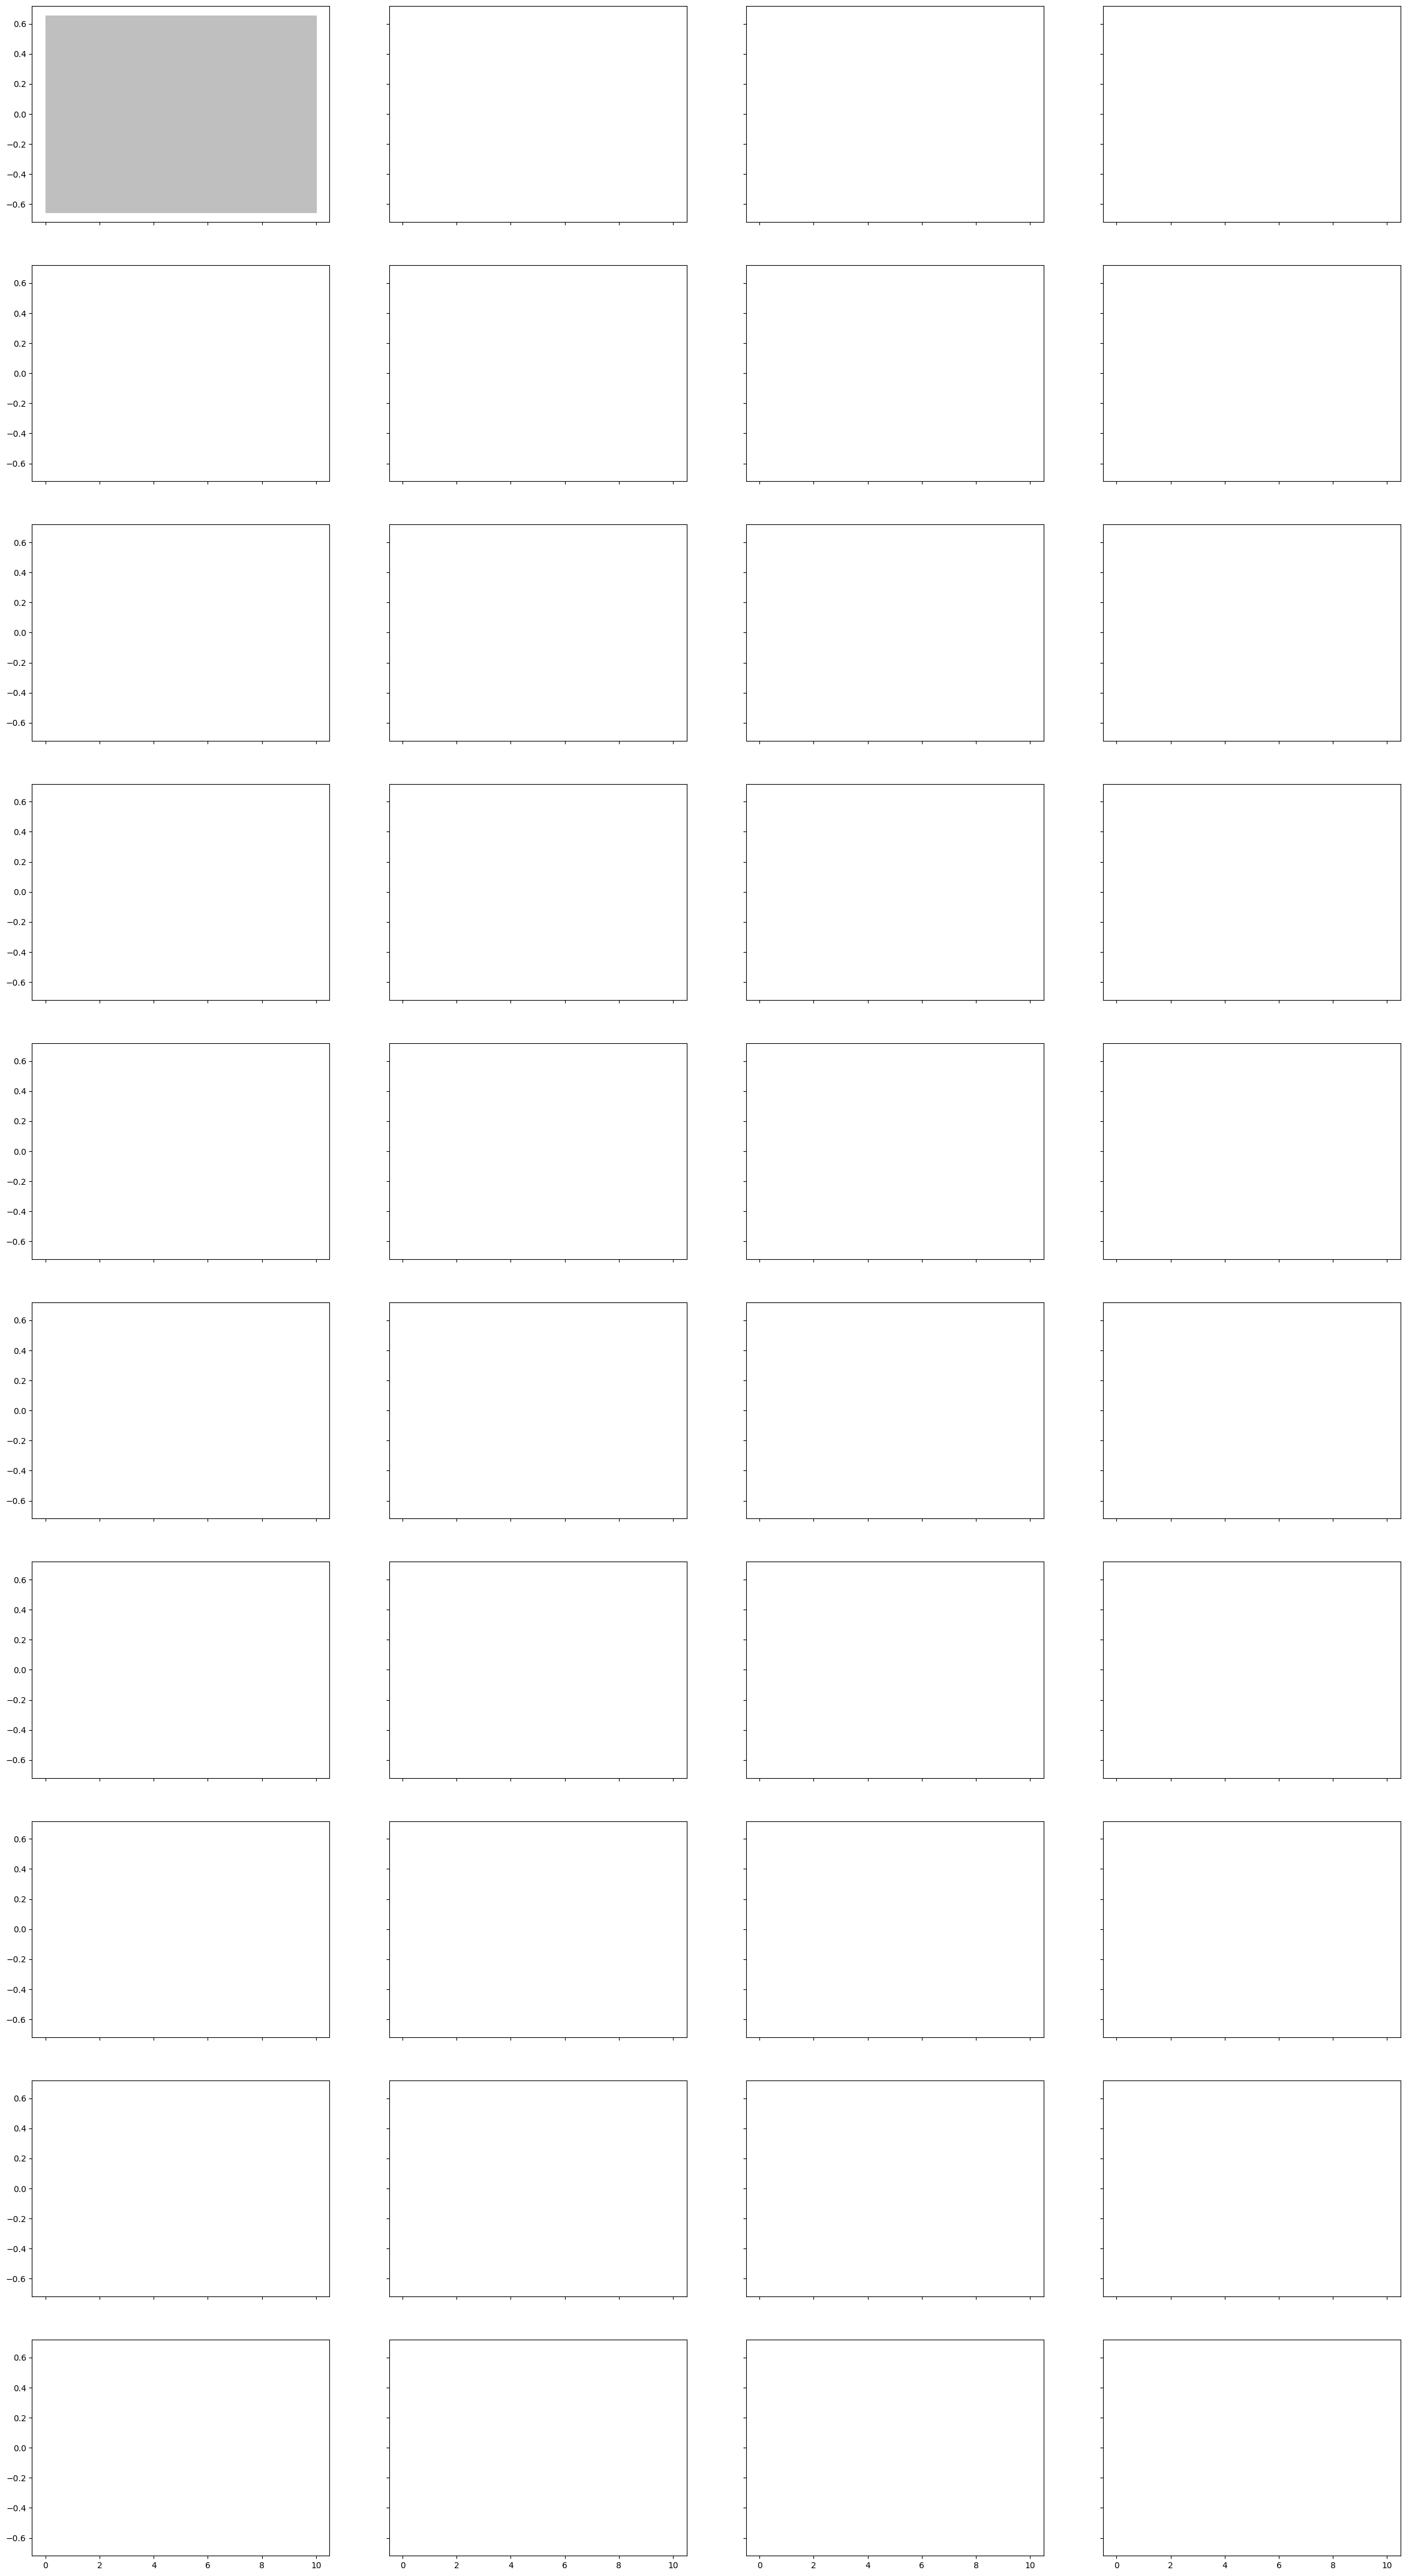

In [9]:
import arviz as az
import xarray as xr
import numpy as np

all_chains_post = all_chains[:, burn_in:, :]  # shape (num_chains, num_steps - burn_in, theta_dim)
thin_interval = 10
all_chains_post_thinn = all_chains_post[:, ::thin_interval, :]  # shape (num_chains, num_steps - burn_in // thin_interval, theta_dim)

# Convert JAX array to numpy if needed
chains_np = np.array(all_chains_post_thinn)  # Shape: (num_chains, num_steps, theta_dim)

# Define parameter names
param_names = ['$t_{end}$', '$M_{plummer}$', '$a_{plummer}$', '$M_{NFW}$', '$r_{NFW}$', '$M_{MN}$', '$a_{MN}$']

# Create multi-index DataFrame
# First, reshape the array to (num_chains * num_steps, theta_dim)
chains_reshaped = chains_np.reshape(-1, chains_np.shape[-1])

# Create multi-index
chain_indices = np.repeat(range(num_chains), chains_np.shape[1])  # [0,0,0,...,1,1,1,...,2,2,2,...]
draw_indices = np.tile(range(chains_np.shape[1]), num_chains)     # [0,1,2,...,0,1,2,...,0,1,2,...]

# Create DataFrame with multi-index
df_multiple_chains = pd.DataFrame(
    chains_reshaped, 
    columns=param_names,
    index=pd.MultiIndex.from_arrays(
        [chain_indices, draw_indices], 
        names=['chain', 'draw']
    )
)

# Convert to xarray Dataset
xdata_multiple_chains = xr.Dataset.from_dataframe(df_multiple_chains)

# Create InferenceData object
idata = az.InferenceData(posterior=xdata_multiple_chains)
# Now you can use all ArviZ diagnostic functions:

# 1. Summary statistics
print(az.summary(idata))

# 2. Trace plots
az.plot_trace(idata)

# 3. R-hat convergence diagnostic
rhat = az.rhat(idata)
print(f"R-hat values:\n{rhat}")

# 4. Effective sample size
ess = az.ess(idata)
print(f"Effective sample size:\n{ess}")

# 5. Autocorrelation plots
az.plot_autocorr(idata, max_lag=10)

# 6. Rank plots (for convergence diagnostics)
az.plot_rank(idata)

# 7. Energy plots (if you have energy/log probability)
# az.plot_energy(idata)

# 8. Posterior plots
az.plot_posterior(idata)

# 9. Corner plot (pair plot)
az.plot_pair(idata, kind='scatter')

# 10. Forest plot
az.plot_forest(idata)

## Plot

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import time 
from functools import partial  # Change this line - lowercase 'partial'

import pandas as pd
import seaborn as sns
from chainconsumer import Chain, ChainConsumer, Truth

from astropy import units as u

code_length = 10.0 * u.kpc
code_mass = 1e4 * u.Msun
code_time = 3 * u.Gyr
code_units = CodeUnits(code_length, code_mass, G=1, unit_time = code_time )  
N_particles = 1000


true_GD1_observation_path = '/export/data/vgiusepp/odisseo_data/data_fix_position/true.npz'
true_theta = np.load(true_GD1_observation_path)['theta'][:1000]
burn_in = 0
# MCMC_1 = np.load('./example_chain_1.npz')['all_chain']
# MCMC_2 = np.load('./example_chain_2.npz')['all_chain']
# MCMC_3 = np.load('./example_chain_3.npz')['all_chain']
# MCMC_4 = np.load('./example_chain_4.npz')['all_chain']
# all_chains = np.concatenate([MCMC_1, MCMC_2, MCMC_3, MCMC_4], axis=0)


MCMC_1 = np.load('./mcmc_numpyro_positions_samples.npz')['samples_log']
# MCMC_2 = np.load('./mcmc_numpyro_samples_1.npz')['samples_log']
# MCMC_3 = np.load('./mcmc_numpyro_samples_2.npz')['samples_log']

# all_chains = np.concatenate([MCMC_1, MCMC_2, MCMC_3], axis=0)


# Which parameters to log-transform? (everything except t_end)
log_mask = jnp.array([False, True, True, True, True, True, True])
def exp_transform(theta_log):
    """Convert log-space vector to linear-space where needed"""
    return jnp.where(log_mask, jnp.exp(theta_log), theta_log)
all_chains = exp_transform(all_chains)

# discard burn-in
all_chains_post = all_chains[:, burn_in:, :]  # shape (num_chains, num_steps - burn_in, theta_dim)

# concatenate along the chain axis
example_chain = all_chains_post.reshape(-1, all_chains_post.shape[-1])

thin = 1
example_chain_thin = example_chain[::thin]

# convert JAX array to numpy
chain_np = np.array(example_chain_thin)

df = pd.DataFrame(chain_np, columns=['$t_{end}$', '$M_{plummer}$', '$a_{plummer}$', '$M_{NFW}$', '$r_{NFW}$', '$M_{MN}$', '$a_{MN}$'])
df = df.astype(float)
df.dropna()
# Convert to float and handle any non-numeric columns
numeric_df = df.select_dtypes(include=[np.number])
if numeric_df.empty:
    # If no numeric columns, convert all to float
    numeric_df = df.astype(float)


# Create corner plot with ChainConsumer
c = ChainConsumer()
c.add_chain(Chain(samples=numeric_df.dropna(), name="Experimental Results", ), )
c.add_truth(Truth(location={
        '$t_{end}$': true_theta[0] * code_units.code_time.to(u.Gyr),
        '$M_{plummer}$': true_theta[1] * code_units.code_mass.to(u.Msun),
        '$a_{plummer}$': true_theta[2] * code_units.code_length.to(u.kpc),
        '$M_{NFW}$': true_theta[3] * code_units.code_mass.to(u.Msun),
        '$r_{NFW}$': true_theta[4] * code_units.code_length.to(u.kpc),
        '$M_{MN}$': true_theta[5] * code_units.code_mass.to(u.Msun),
        '$a_{MN}$': true_theta[6] * code_units.code_length.to(u.kpc),
}))
fig = c.plotter.plot()   


TypeError: Error interpreting argument to <function exp at 0x7c59f72809a0> as an abstract array. The problematic value is of type <class 'numpy.ndarray'> and was passed to the function at path x.
This typically means that a jit-wrapped function was called with a non-array argument, and this argument was not marked as static using the static_argnums or static_argnames parameters of jax.jit.

In [9]:
all_chains = np.load('./NUTS_new.npz', allow_pickle=True)

In [10]:
all_chains['chains']

array({'M_MN': Array([[9.161840e+10, 9.161840e+10, 9.161840e+10, ..., 9.161840e+10,
        9.161840e+10, 9.161840e+10],
       [7.070621e+10, 7.070621e+10, 7.070621e+10, ..., 7.070621e+10,
        7.070621e+10, 7.070621e+10],
       [3.668788e+10, 3.668788e+10, 3.668788e+10, ..., 3.668788e+10,
        3.668788e+10, 3.668788e+10]], dtype=float32), 'M_NFW': Array([[7.8037123e+11, 7.8037123e+11, 7.8037123e+11, ..., 7.8037123e+11,
        7.8037123e+11, 7.8037123e+11],
       [7.1366725e+11, 7.1366725e+11, 7.1366725e+11, ..., 7.1366725e+11,
        7.1366725e+11, 7.1366725e+11],
       [7.0558129e+11, 7.0558129e+11, 7.0558129e+11, ..., 7.0558129e+11,
        7.0558129e+11, 7.0558129e+11]], dtype=float32), 'Mtot': Array([[15199.575, 15199.575, 15199.575, ..., 15199.575, 15199.575,
        15199.575],
       [12664.456, 12664.456, 12664.456, ..., 12664.456, 12664.456,
        12664.456],
       [24881.533, 24881.533, 24881.533, ..., 24881.533, 24881.533,
        24881.533]], dtype=float32),

/export/home/vgiusepp/miniconda3/envs/sbi_sim/lib/python3.12/site-packages/arviz/stats/diagnostics.py:990: RuntimeWarning: overflow encountered in square
  varvar = ((sims_c2**2).mean() - evar**2) / ess_mean_sims
/export/home/vgiusepp/miniconda3/envs/sbi_sim/lib/python3.12/site-packages/arviz/stats/diagnostics.py:990: RuntimeWarning: overflow encountered in scalar power
  varvar = ((sims_c2**2).mean() - evar**2) / ess_mean_sims
/export/home/vgiusepp/miniconda3/envs/sbi_sim/lib/python3.12/site-packages/arviz/stats/diagnostics.py:990: RuntimeWarning: invalid value encountered in scalar subtract
  varvar = ((sims_c2**2).mean() - evar**2) / ess_mean_sims
/export/home/vgiusepp/miniconda3/envs/sbi_sim/lib/python3.12/site-packages/arviz/stats/diagnostics.py:990: RuntimeWarning: overflow encountered in square
  varvar = ((sims_c2**2).mean() - evar**2) / ess_mean_sims
/export/home/vgiusepp/miniconda3/envs/sbi_sim/lib/python3.12/site-packages/arviz/stats/diagnostics.py:990: RuntimeWarning: overf

                       mean            sd        hdi_3%       hdi_97%  \
$t_{end}$      3.191000e+00  1.443000e+00  5.330000e-01  4.981000e+00   
$M_{plummer}$  4.477588e+03  2.949139e+03  1.074823e+03  9.209763e+03   
$a_{plummer}$  5.000000e-03  3.000000e-03  2.000000e-03  1.100000e-02   
$M_{NFW}$      3.172461e+11  2.146674e+11  1.403723e+11  6.985031e+11   
$r_{NFW}$      1.043800e+01  7.161000e+00  4.225000e+00  2.501600e+01   
$M_{MN}$       7.212138e+10  3.999527e+10  2.184808e+10  1.297304e+11   
$a_{MN}$       2.589000e+00  1.199000e+00  9.280000e-01  3.854000e+00   

                  mcse_mean  mcse_sd  ess_bulk  ess_tail         r_hat  
$t_{end}$      5.890000e-01    0.348       6.0       6.0  7.825542e+15  
$M_{plummer}$  1.203499e+03  470.621       6.0       6.0  7.825542e+15  
$a_{plummer}$  1.000000e-03    0.001       6.0       6.0  7.192901e+15  
$M_{NFW}$      8.760255e+10      NaN       6.0       6.0  7.192901e+15  
$r_{NFW}$      2.922000e+00    2.073       6.0    

/export/home/vgiusepp/miniconda3/envs/sbi_sim/lib/python3.12/site-packages/arviz/stats/density_utils.py:488: UserWarning: Your data appears to have a single value or no finite values
  warnings.warn("Your data appears to have a single value or no finite values")
/export/home/vgiusepp/miniconda3/envs/sbi_sim/lib/python3.12/site-packages/arviz/stats/density_utils.py:488: UserWarning: Your data appears to have a single value or no finite values
  warnings.warn("Your data appears to have a single value or no finite values")
/export/home/vgiusepp/miniconda3/envs/sbi_sim/lib/python3.12/site-packages/arviz/stats/density_utils.py:488: UserWarning: Your data appears to have a single value or no finite values
  warnings.warn("Your data appears to have a single value or no finite values")
/export/home/vgiusepp/miniconda3/envs/sbi_sim/lib/python3.12/site-packages/arviz/stats/density_utils.py:488: UserWarning: Your data appears to have a single value or no finite values
  warnings.warn("Your data a

ValueError: Too many bins for data range. Cannot create 512 finite-sized bins.

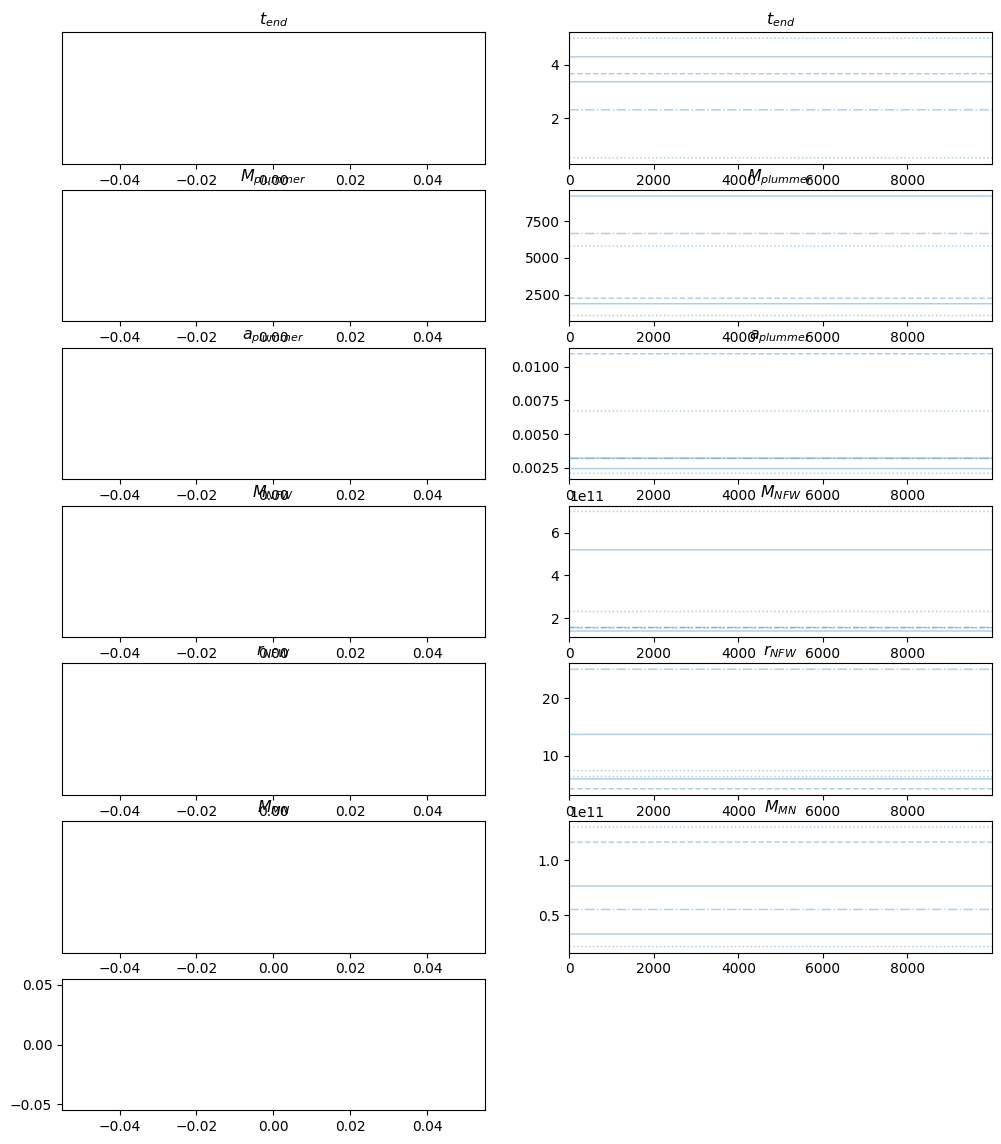

In [7]:
import arviz as az
import xarray as xr
import numpy as np

num_chains = all_chains.shape[0]
# all_chains_post = all_chains[:, burn_in:, :]  # shape (num_chains, num_steps - burn_in, theta_dim)
# thin_interval = 10
# all_chains_post_thinn = all_chains_post[:, ::thin_interval, :]  # shape (num_chains, num_steps - burn_in // thin_interval, theta_dim)

# Convert JAX array to numpy if needed
# chains_np = np.array(all_chains_post_thinn)  # Shape: (num_chains, num_steps, theta_dim)
chains_np = np.array(all_chains)  # Shape: (num_chains, num_steps, theta_dim)
# Define parameter names
param_names = ['$t_{end}$', '$M_{plummer}$', '$a_{plummer}$', '$M_{NFW}$', '$r_{NFW}$', '$M_{MN}$', '$a_{MN}$']

# Create multi-index DataFrame
# First, reshape the array to (num_chains * num_steps, theta_dim)
chains_reshaped = chains_np.reshape(-1, chains_np.shape[-1])

# Create multi-index
chain_indices = np.repeat(range(num_chains), chains_np.shape[1])  # [0,0,0,...,1,1,1,...,2,2,2,...]
draw_indices = np.tile(range(chains_np.shape[1]), num_chains)     # [0,1,2,...,0,1,2,...,0,1,2,...]

# Create DataFrame with multi-index
df_multiple_chains = pd.DataFrame(
    chains_reshaped, 
    columns=param_names,
    index=pd.MultiIndex.from_arrays(
        [chain_indices, draw_indices], 
        names=['chain', 'draw']
    )
)

# Convert to xarray Dataset
xdata_multiple_chains = xr.Dataset.from_dataframe(df_multiple_chains)

# Create InferenceData object
idata = az.InferenceData(posterior=xdata_multiple_chains)
# Now you can use all ArviZ diagnostic functions:

# 1. Summary statistics
print(az.summary(idata))

# 2. Trace plots
az.plot_trace(idata)

# 3. R-hat convergence diagnostic
rhat = az.rhat(idata)
print(f"R-hat values:\n{rhat}")

# 4. Effective sample size
ess = az.ess(idata)
print(f"Effective sample size:\n{ess}")

# 5. Autocorrelation plots
az.plot_autocorr(idata, max_lag=10)

# 6. Rank plots (for convergence diagnostics)
az.plot_rank(idata)

# 7. Energy plots (if you have energy/log probability)
# az.plot_energy(idata)

# 8. Posterior plots
az.plot_posterior(idata)

# 9. Corner plot (pair plot)
az.plot_pair(idata, kind='scatter')

# 10. Forest plot
az.plot_forest(idata)

In [8]:
import arviz as az
import xarray as xr

num_chains = 6

thin = 1
all_chains_post_thinned = all_chains_post[:, ::thin]

# Convert JAX array to numpy if needed
chains_np = np.array(all_chains_post)  # Shape: (num_chains, num_steps, theta_dim)

# Define parameter names
param_names = ['$t_{end}$', '$M_{plummer}$', '$a_{plummer}$', '$M_{NFW}$', '$r_{NFW}$', '$M_{MN}$', '$a_{MN}$']

# Create multi-index DataFrame
# First, reshape the array to (num_chains * num_steps, theta_dim)
chains_reshaped = chains_np.reshape(-1, chains_np.shape[-1])

# Create multi-index
chain_indices = np.repeat(range(num_chains), chains_np.shape[1])  # [0,0,0,...,1,1,1,...,2,2,2,...]
draw_indices = np.tile(range(chains_np.shape[1]), num_chains)     # [0,1,2,...,0,1,2,...,0,1,2,...]

# Create DataFrame with multi-index
df_multiple_chains = pd.DataFrame(
    chains_reshaped, 
    columns=param_names,
    index=pd.MultiIndex.from_arrays(
        [chain_indices, draw_indices], 
        names=['chain', 'draw']
    )
)

# Convert to xarray Dataset
xdata_multiple_chains = xr.Dataset.from_dataframe(df_multiple_chains)

# Create InferenceData object
idata = az.InferenceData(posterior=xdata_multiple_chains)



In [6]:
idata

NameError: name 'idata' is not defined

/export/home/vgiusepp/miniconda3/envs/sbi_sim/lib/python3.12/site-packages/arviz/stats/density_utils.py:488: UserWarning: Your data appears to have a single value or no finite values
  warnings.warn("Your data appears to have a single value or no finite values")
/export/home/vgiusepp/miniconda3/envs/sbi_sim/lib/python3.12/site-packages/arviz/stats/density_utils.py:488: UserWarning: Your data appears to have a single value or no finite values
  warnings.warn("Your data appears to have a single value or no finite values")
/export/home/vgiusepp/miniconda3/envs/sbi_sim/lib/python3.12/site-packages/arviz/stats/density_utils.py:488: UserWarning: Your data appears to have a single value or no finite values
  warnings.warn("Your data appears to have a single value or no finite values")
/export/home/vgiusepp/miniconda3/envs/sbi_sim/lib/python3.12/site-packages/arviz/stats/density_utils.py:488: UserWarning: Your data appears to have a single value or no finite values
  warnings.warn("Your data a

ValueError: Too many bins for data range. Cannot create 512 finite-sized bins.

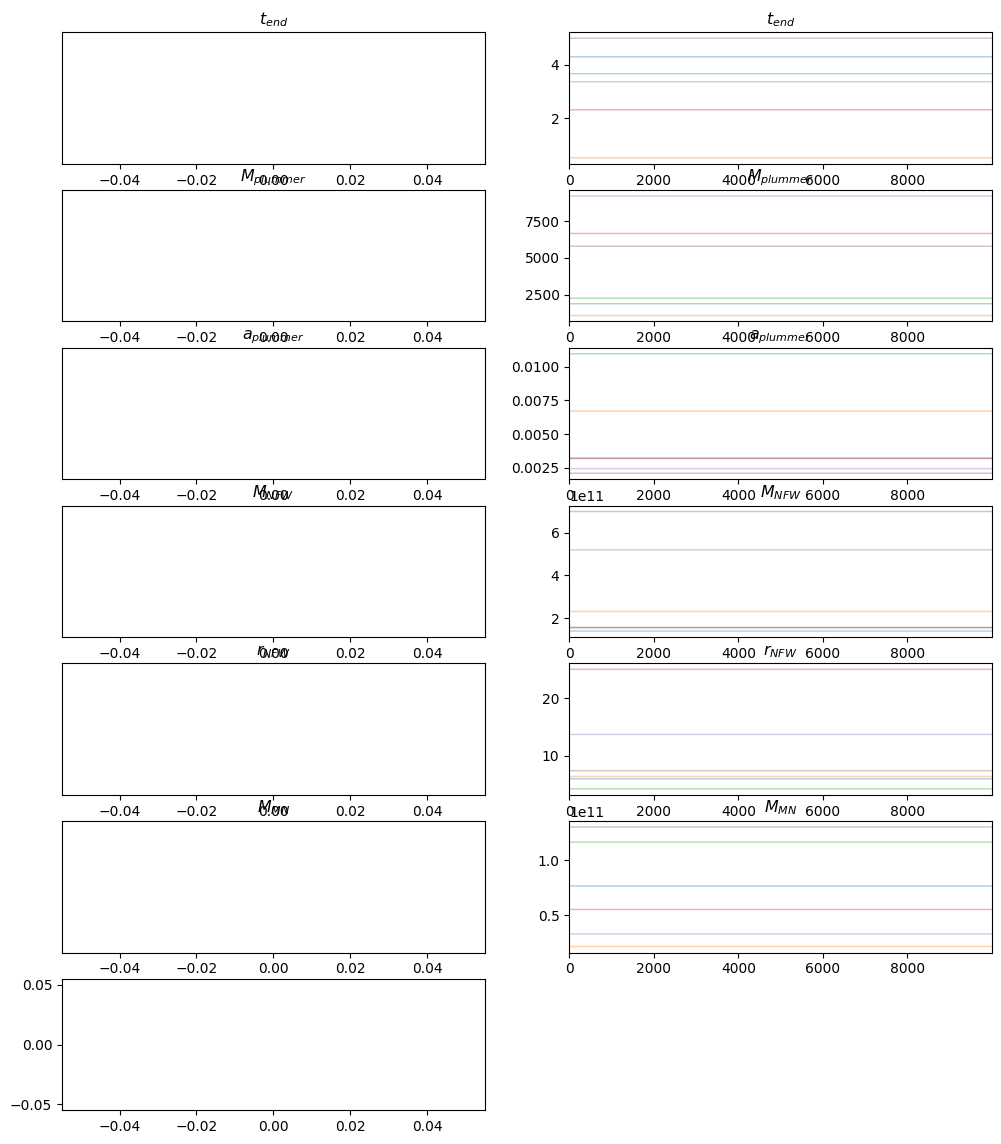

In [9]:
az.plot_trace(idata, compact=False);